<a href="https://colab.research.google.com/github/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/blob/eleojosunday2002-ai-patch/Imbalance_Handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the feature data and attach the churn label from the cleaned dataset.

In [1]:
import pandas as pd

features_url = "https://raw.githubusercontent.com/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/main/Complete%20Data-Group%205/4.%20Clustered_Features.csv"
cleaned_url = "https://raw.githubusercontent.com/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/main/Complete%20Data-Group%205/2.%20Cleaned_Bank_Churners.csv"

features = pd.read_csv(features_url)
cleaned = pd.read_csv(cleaned_url)

print(features.shape)
print(cleaned.shape)

(10127, 36)
(10127, 20)


Check the class imbalance to see how many stayed vs churned

In [2]:
features['Attrition_Flag'] = cleaned['Attrition_Flag']

print(features['Attrition_Flag'].value_counts())

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64


Baseline model shows no imbalance handling for comparison

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = features.drop(columns=['Attrition_Flag'])
y = features['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1701
           1       0.81      0.61      0.70       325

    accuracy                           0.91      2026
   macro avg       0.87      0.79      0.82      2026
weighted avg       0.91      0.91      0.91      2026



In [ ]:
Technique 1: Class Weights tells the model to pay more attention to churners.

In [4]:
weighted_model = LogisticRegression(max_iter=1000, class_weight='balanced')
weighted_model.fit(X_train, y_train)

y_pred_weighted = weighted_model.predict(X_test)
print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92      1701
           1       0.58      0.86      0.70       325

    accuracy                           0.88      2026
   macro avg       0.78      0.87      0.81      2026
weighted avg       0.91      0.88      0.89      2026



Technique 2: SMOTE creates synthetic churner examples to balance the data.

In [5]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93      1701
           1       0.59      0.84      0.70       325

    accuracy                           0.88      2026
   macro avg       0.78      0.87      0.81      2026
weighted avg       0.91      0.88      0.89      2026



Precision-Recall curve shows the trade-off as we adjust the decision threshold.

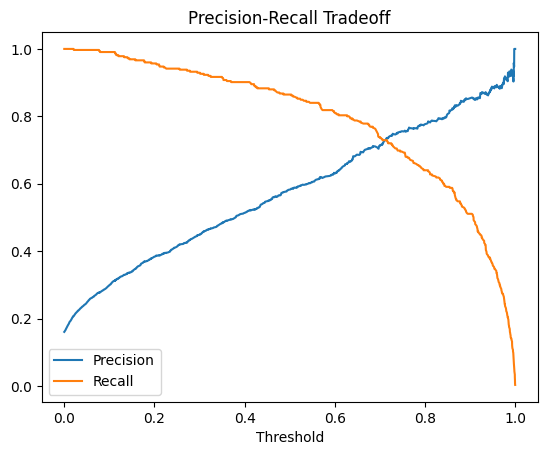

In [6]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = weighted_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall Tradeoff')
plt.show()

Technique 3: Threshold Tuning lowers the cutoff to catch more churners.

In [7]:
custom_threshold = 0.3
y_pred_custom = (y_probs >= custom_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.98      0.78      0.87      1701
           1       0.45      0.93      0.61       325

    accuracy                           0.81      2026
   macro avg       0.72      0.86      0.74      2026
weighted avg       0.90      0.81      0.83      2026

